
<center><font size=10>Generative AI for Business Applications</center></font>
<center><font size=6>AI Foundations - ML- Week 1</center></font>

<center><p float="center">
  <img src="https://raw.githubusercontent.com/Masterx-AI/Project_Insurance_Claim_Anticipation_/main/ica.jpg" alt="DALL-E-2025-02-27-15-47-37-An-international-outdoor-DTH-store-labeled-AUTHORIZED-DTH-OUTLET-with-a-m"width=700></a>
<center><font size=6>Health Insurance Premium Prediction</center></font>

# **Problem Statement**

## Business Context

Rising healthcare costs and growing demand for affordable coverage are pushing insurers to sharpen their pricing strategies. Accurately predicting premiums—based on factors like age, BMI, and smoking status—is now essential for balancing customer satisfaction with financial viability. Predictive analytics helps insurers price risk more precisely and stay competitive while keeping coverage affordable.

## Objective

This study aims to build a predictive model that estimates health insurance charges from demographic and personal factors, helping insurers make data-driven pricing decisions.

The approach involves collecting and preprocessing data, selecting key features (age, BMI, smoking status), and building a linear regression model evaluated using MSE and R-squared. These insights help segment customers by risk profile, enabling more refined pricing and engagement strategies—improving competitiveness, affordability, and customer satisfaction.

## Data Description


The dataset consists of several key attributes:

- **Age**: Numerical value representing the age of the insured individual.
- **Sex**: Categorical variable indicating gender (male or female).
- **BMI**: Numerical value reflecting the Body Mass Index, a measure of body fat based on height and weight.
- **Children**: Numerical value representing the number of dependent children covered by the insurance policy.
- **Smoker**: Categorical variable indicating whether the individual is a smoker (yes or no).
- **Region**: Categorical variable that identifies the geographic area of the insured (southwest, southeast, northwest, northeast).
- **Charges**: Numerical value indicating the annual insurance premium (in USD) incurred by the policyholder.

This dataset contains a diverse range of cases, facilitating the modeling of different demographic and health profiles to predict insurance charges effectively.


# **Installing and Importing Necessary Libraries**

Before diving into data analysis and model development, we first import all the necessary Python libraries that will support various stages of this machine learning pipeline. These libraries help with data manipulation, visualization, model building, and evaluation:

- **NumPy** and **Pandas** for efficient numerical and data manipulation.
- **Matplotlib** and **Seaborn** for insightful data visualizations.
- **Scikit-learn** for building and evaluating machine learning models.
- Additional libraries as needed for preprocessing and tuning.

With these tools in hand, we are now equipped to begin our data-driven journey into predicting insurance prices.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import libraries for reading and manipulating data
import pandas as pd
# Import library for numerical operations
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Import utilities for performance evaluation
from sklearn.metrics import mean_squared_error, r2_score

# Import utilities for data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# **Loading the Data**

We load the insurance dataset using Pandas — it contains 1,338 records with age, sex, BMI, children, smoker status, region, and charges. Let's take a first look at its structure.



In [ ]:
data = pd.read_csv('/content/drive/MyDrive/GenAI/Health Insurance Prediction_ML/insurance_prediction.csv')


# **Data Overview**

Before proceeding with analysis, we perform a structural review of the dataset — examining its dimensions, sample records, feature data types, and any missing values or anomalies. This overview informs the preprocessing steps required and confirms the data is clean and analysis-ready.

In [ ]:
data.shape

(1338, 7)

The dataset consists of 1,338 rows and 7 columns

In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


- The dataset contains **7 columns** and **1338 rows**, with **no missing values**.
- Data types are as expected:  
  - **Numeric:** `age`, `bmi`, `children`, `charges`  
  - **Categorical:** `sex`, `smoker`, `region`

To Check Duplicates

In [ ]:
# Identify duplicate rows
duplicate_rows = data[data.duplicated()]

# Print the number of duplicate rows
print(f"Number of duplicate rows: {len(duplicate_rows)}")

# Display the duplicate rows (optional)
duplicate_rows


Number of duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


To Remove Duplicates

In [ ]:
# Drop duplicate rows
data = data.drop_duplicates()

# Print the shape of the DataFrame after removing duplicates
print(f"Shape after removing duplicates: {data.shape}")


Shape after removing duplicates: (1337, 7)


There were originally 1,338 rows. After removing 1 duplicate record, the dataset now contains 1,337 records.

Numerical summary

In [ ]:
data.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


Categorical summary

In [ ]:
data.describe(include='object')

,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


# **Exploratory Data Analysis**

Graph 1 — Charges by BMI Category and Smoker

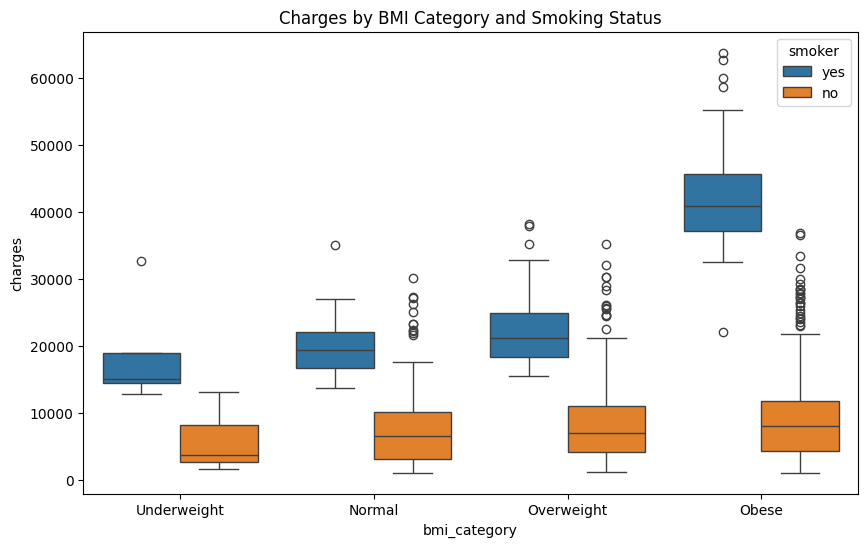

In [ ]:
def bmi_category(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 25: return 'Normal'
    elif bmi < 30: return 'Overweight'
    else: return 'Obese'

def family_size(children):
    if children == 0: return 'No Children'
    elif children <= 2: return 'Small Family'
    else: return 'Large Family'

# Create a copy just for EDA visuals — original 'data' stays untouched
eda_data = data.copy()

eda_data['bmi_category'] = eda_data['bmi'].apply(bmi_category)
eda_data['age_group'] = pd.cut(eda_data['age'], bins=[17,25,35,45,55,65],
                                 labels=['18-25','26-35','36-45','46-55','56-64'])
eda_data['family_size'] = eda_data['children'].apply(family_size)

plt.figure(figsize=(10, 6))
sns.boxplot(x='bmi_category', y='charges', hue='smoker', data=eda_data,
            order=['Underweight', 'Normal', 'Overweight', 'Obese'])
plt.title('Charges by BMI Category and Smoking Status')
plt.show()


Insight: BMI alone barely moves charges for non-smokers — but obese smokers form a distinct, dramatically higher-cost cluster. BMI only matters when combined with smoking.

Graph 2 — Charges by Age Group and Smoker

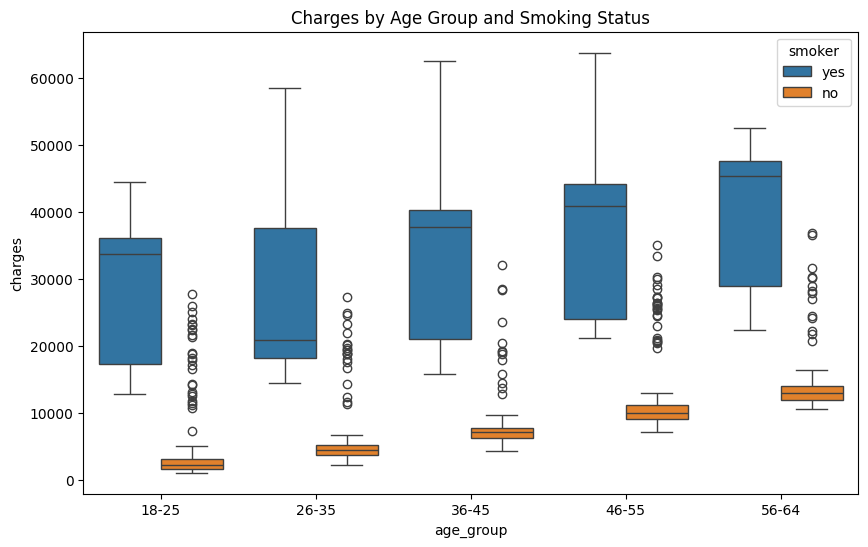

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='age_group', y='charges', hue='smoker', data=eda_data)
plt.title('Charges by Age Group and Smoking Status')
plt.show()


Insight: Non-smoker charges rise gently with age; smoker charges stay elevated at every age group — even young smokers pay as much as older non-smokers. This explains the "3 clusters" seen earlier in the age-vs-charges scatterplot.

Graph 3 — How Much Do Most People Actually Pay?

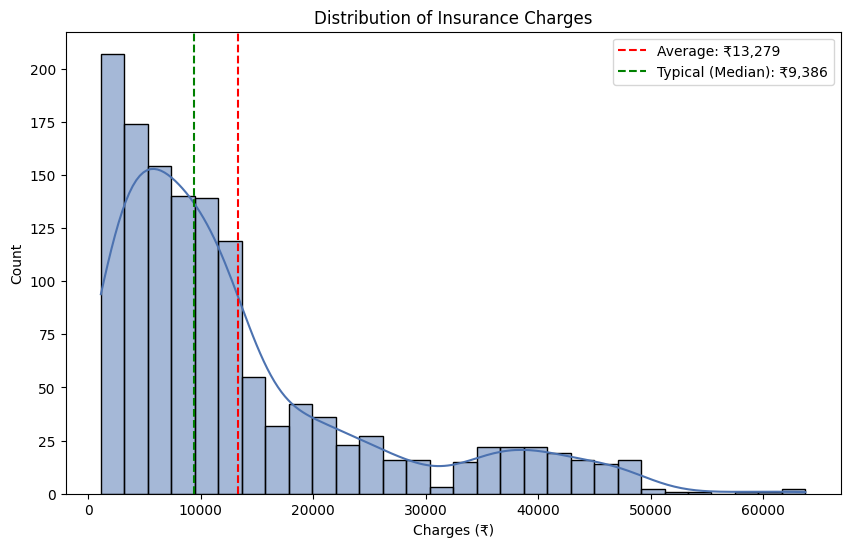

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data['charges'], bins=30, kde=True, color='#4C72B0')
plt.axvline(data['charges'].mean(), color='red', linestyle='--', label=f"Average: ₹{data['charges'].mean():,.0f}")
plt.axvline(data['charges'].median(), color='green', linestyle='--', label=f"Typical (Median): ₹{data['charges'].median():,.0f}")
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges (₹)')
plt.legend()
plt.show()


Insight: Most customers pay well below the average — a small group of very high-cost cases (mostly smokers) pulls the average upward. This is why looking at the "average customer" alone can be misleading when setting prices; the pricing strategy needs to account for this small, high-cost group separately.

# **Data Preprocessing**

Categorical variables (sex, smoker, region) must be encoded into numeric form before modeling, since they showed strong influence on charges during EDA.
One-hot encoding avoids introducing false ordinal relationships between categories.
Data is split 70–30 into training and test sets to fairly evaluate how well the model generalizes to unseen customers.


### Encode the Data

In [ ]:
data = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)


In [ ]:
data.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


### Train Test Split

In [ ]:
# Split data into features (X) and target (y)
X = data.drop('charges', axis=1)
y = data['charges']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (935, 8)
X_test shape: (402, 8)
y_train shape: (935,)
y_test shape: (402,)


The training and testing datasets are properly split, with approximately 70% of the data used for training and 30% for testing.

# **Model Building**

## Model Building

With the data preprocessed and ready, we begin our modeling phase using **Linear Regression**, a foundational and interpretable algorithm for predicting continuous outcomes.

Linear Regression assumes a linear relationship between the input features and the target variable in this case, **insurance charges**. It attempts to fit the best possible straight line through the data that minimizes the difference between the predicted and actual values.

**Model Training**

We train the linear regression model on our training dataset, allowing it to learn the relationship between the independent variables (like age, BMI, smoker status, etc.) and the dependent variable (charges).


Creating a blank DataFrame to store the training and testing metrics of different models.

In [ ]:
# A blank DataFrame named model_eval_results to store the performance results of different models on the training and testing sets.

model_eval_results = pd.DataFrame(columns=['Model', 'Train_MSE', 'Train_R2', 'Test_MSE', 'Test_R2'])

### Model 1

In [ ]:
# Define features (X) and target (y) for Model 1 (Age only)
X_train_m1 = X_train[['age']]
X_test_m1 = X_test[['age']]

# Initialize and train the Linear Regression model
model_1 = LinearRegression()
model_1.fit(X_train_m1, y_train)

LinearRegression()

In [ ]:
print(f'Linear Regression Equation: Charges = {model_1.intercept_:.2f} + ({model_1.coef_[0]:.2f} * Age)')

- Based on the above equation, we can say that insurance premium charges increase as the age of the customer increases.

- It's important to note that it's important to check if the assumptions of linear regression are satisfied before we can make a proper inference from the model coefficients.
    - While the assumptions are out of the scope of the program, you can refer to the reference material of the week in case you're interested in exploring further.

Evaluating the model's performance.

In [ ]:

# Predict on training and testing data
y_train_pred_m1 = model_1.predict(X_train_m1)
y_test_pred_m1 = model_1.predict(X_test_m1)

# Calculate MSE and R2 for training data
train_mse_m1 = mean_squared_error(y_train, y_train_pred_m1)
train_r2_m1 = r2_score(y_train, y_train_pred_m1)

# Calculate MSE and R2 for testing data
test_mse_m1 = mean_squared_error(y_test, y_test_pred_m1)
test_r2_m1 = r2_score(y_test, y_test_pred_m1)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 1 (Age Only)', train_mse_m1, train_r2_m1, test_mse_m1, test_r2_m1]

# Display the results
model_eval_results


,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985


- The error is high and the R-squared value is low for both the training and testing datasets, indicating poor model performance and underfitting.
- This is likely due to the use of only a single feature and a simple linear model.

### Model 2

In [ ]:
# Define features (X) and target (y) for Model 2 (Age and BMI)
X_train_m2 = X_train[['age', 'bmi']]
X_test_m2 = X_test[['age', 'bmi']]

# Initialize and train the Linear Regression model
model_2 = LinearRegression()
model_2.fit(X_train_m2, y_train)

LinearRegression()

In [ ]:
print(f'Linear Regression Equation: Charges = {model_2.intercept_:.2f} + ({model_2.coef_[0]:.2f} * Age) + ({model_2.coef_[1]:.2f} * BMI)')


- Based on the above equation, we can say that insurance premium charges increase as the BMI of the customer increases, provided that the age is held constant.

- It's important to note that it's important to check if the assumptions of linear regression are satisfied before we can make a proper inference from the model coefficients.
    - While the assumptions are out of the scope of the program, you can refer to the reference material of the week in case you're interested in exploring further.

Evaluating the model's performance.

In [ ]:
# Evaluate the model’s performance on both the training and testing data, add it to model_eval_results, and display the results.

# Predict on training and testing data
y_train_pred_m2 = model_2.predict(X_train_m2)
y_test_pred_m2 = model_2.predict(X_test_m2)

# Calculate MSE and R2 for training data
train_mse_m2 = mean_squared_error(y_train, y_train_pred_m2)
train_r2_m2 = r2_score(y_train, y_train_pred_m2)

# Calculate MSE and R2 for testing data
test_mse_m2 = mean_squared_error(y_test, y_test_pred_m2)
test_r2_m2 = r2_score(y_test, y_test_pred_m2)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 2 (Age and BMI)', train_mse_m2, train_r2_m2, test_mse_m2, test_r2_m2]

# Display the results
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338


- The error has reduced slightly, but is still high, and the R-squared value is low for both the training and testing data, indicating that the model is still performing poorly and **underfitting**.


### Model 3

In [ ]:
# Initialize and train the Linear Regression model on the whole data (all features)
model_3 = LinearRegression()
model_3.fit(X_train, y_train)


LinearRegression()

In [ ]:
# Construct the equation string
equation = f'Charges = {model_3.intercept_:.2f}'
for i, col in enumerate(X_train.columns):
    equation += f' + ({model_3.coef_[i]:.2f} * {col})'

print(f'Linear Regression Equation: {equation}')

Linear Regression Equation: Charges = -11516.78 + (251.25 * age) + (328.38 * bmi) + (522.16 * children) + (-111.91 * sex_male) + (22874.45 * smoker_yes) + (-465.75 * region_northwest) + (-936.10 * region_southeast) + (-765.58 * region_southwest)


In [ ]:
# Evaluate the model’s performance on both the training and testing data, add it to model_eval_results, and display the results.

# Predict on training and testing data
y_train_pred_m3 = model_3.predict(X_train)
y_test_pred_m3 = model_3.predict(X_test)

# Calculate MSE and R2 for training data
train_mse_m3 = mean_squared_error(y_train, y_train_pred_m3)
train_r2_m3 = r2_score(y_train, y_train_pred_m3)

# Calculate MSE and R2 for testing data
test_mse_m3 = mean_squared_error(y_test, y_test_pred_m3)
test_r2_m3 = r2_score(y_test, y_test_pred_m3)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 3 (All Features)', train_mse_m3, train_r2_m3, test_mse_m3, test_r2_m3]

# Display the results
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338
2,Model 3 (All Features),3.581293e+07,0.736264,3.894017e+07,0.772436


- The training and testing R-squared values are close (0.736 and 0.772), with MSE values similarly close, indicating the model is generalizing well, **not overfitting**, and performing well on unseen data.

## Model Comparison and Final Model Selecttion

In [ ]:
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338
2,Model 3 (All Features),3.581293e+07,0.736264,3.894017e+07,0.772436


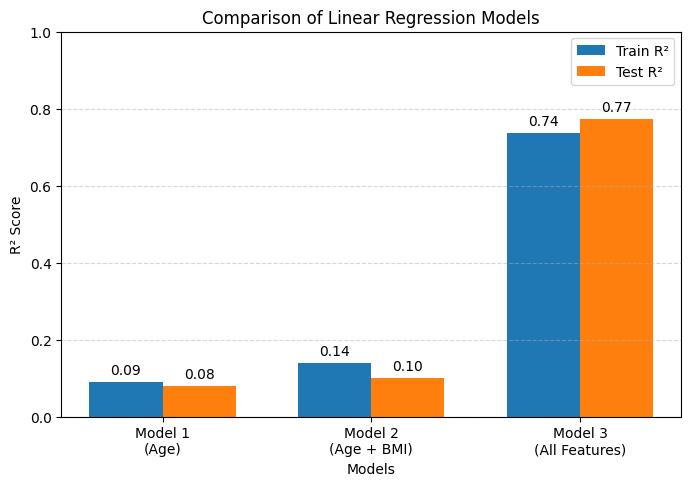

In [ ]:
# Model names
models = ['Model 1\n(Age)', 'Model 2\n(Age + BMI)', 'Model 3\n(All Features)']

# Replace these values with your actual notebook values
train_r2 = [0.09, 0.14, 0.736]
test_r2 = [0.08, 0.10, 0.772]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, train_r2, width, label='Train R²')
plt.bar(x + width/2, test_r2, width, label='Test R²')

plt.xticks(x, models)
plt.ylabel('R² Score')
plt.xlabel('Models')
plt.title('Comparison of Linear Regression Models')
plt.ylim(0, 1)

# Display values on bars
for i, v in enumerate(train_r2):
    plt.text(i - width/2, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)

for i, v in enumerate(test_r2):
    plt.text(i + width/2, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

As we progress from Model 1 to Model 3, we observe a significant improvement in performance:

* **Model 1 (Age)** uses only a single feature and performs the worst, with a very high error and low R² values.
* **Model 2 (Age + BMI)** slightly improves both error and R², but still underperforms.
* **Model 3 (All Features)** shows a **drastic reduction in error** and a **substantial increase in R²**, indicating that it explains a much higher proportion of the variance in the target variable.

**Therefore, Model 3, which incorporates all available features, is the best performing model. It is selected as the final model due to its significantly better predictive accuracy and model fit.**

# **Predicting on Unseen Data**

Now that we've selected **Model 3** (Linear Regression using all features) as our final model, the real value of this project comes from using it to predict premiums for **new, unseen customers** — people who are not in our original dataset.

In [ ]:
new_customers = pd.DataFrame([
    {'age': 25, 'bmi': 22.1, 'children': 0, 'sex_male': 0, 'smoker_yes': 0,
     'region_northwest': 1, 'region_southeast': 0, 'region_southwest': 0},

    {'age': 52, 'bmi': 31.4, 'children': 3, 'sex_male': 1, 'smoker_yes': 1,
     'region_northwest': 0, 'region_southeast': 0, 'region_southwest': 1},

    {'age': 40, 'bmi': 28.9, 'children': 1, 'sex_male': 0, 'smoker_yes': 0,
     'region_northwest': 0, 'region_southeast': 1, 'region_southwest': 0},
])

predictions = model_3.predict(new_customers)
new_customers['Predicted_Charges'] = predictions.round(2)
new_customers

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,Predicted_Charges
0,25,22.1,0,0,0,1,0,0,1555.89
1,52,31.4,3,1,1,0,0,1,35422.67
2,40,28.9,1,0,0,0,1,0,7609.39


Running **Model 3** on three unseen customers produced predicted premiums of ₹**1,555.89**, ₹**35,422.67,** and ₹**7,609.39** respectively. The results align well with the patterns observed during EDA — the 25-year-old non-smoking female with a normal BMI received the lowest predicted charge, while the 52-year-old male smoker with three children was predicted to pay dramatically more (over 20x the first customer), confirming smoking status as the strongest driver of insurance cost. The third customer, a 40-year-old non-smoking female with a slightly elevated BMI, received a moderate premium in between, consistent with age and BMI having a smaller but still positive influence on charges. This confirms that the model isn't just fitting the training data blindly — it's applying the real-world relationships it learned (smoker >> age > BMI > children) sensibly to new, unseen profiles.

# **Conclusion**

This project set out to answer a simple but important question: what should a health insurance customer actually pay, and why?

The data gave a clear answer. Smoking status is the single biggest factor in a customer's premium — smokers pay dramatically more than non-smokers, regardless of age or BMI. Age and BMI both push premiums up too, but far more modestly, and mostly matter in combination with smoking rather than on their own. Family size and region, by contrast, have almost no effect on cost.

Starting from a simple model based on age alone, and building up to a full model using all customer information, prediction accuracy improved substantially — confirming that a customer's full risk profile, not just one factor, is needed to price fairly.

For the business, this points to a clear path forward: price aggressively on smoking status and age, invest in wellness and smoking-cessation programs to shift customers into lower-risk (and lower-cost) categories, and avoid over-engineering pricing around factors like region or family size that don't meaningfully affect cost. Done well, this turns pricing from a guessing game into a data-backed decision — protecting the company's financial health while keeping coverage fair and competitive for customers.